In [58]:
import numpy as np
import pandas as pd
import os
import kagglehub

In [59]:
path = kagglehub.dataset_download("nelgiriyewithana/global-weather-repository")
df = pd.read_csv(os.path.join(path, "GlobalWeatherRepository.csv"))

pd.set_option('display.max_columns', None)

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [60]:
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Cities: {df['location_name'].nunique()}  |  Countries: {df['country'].nunique()}")

dates = pd.to_datetime(df['last_updated'], errors='coerce')
print(f"Date range: {dates.min().date()} to {dates.max().date()}")

143,847 rows, 41 columns
Cities: 257  |  Countries: 211
Date range: 2024-05-16 to 2026-05-27


In [61]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,143847.000000,143847.000000,1.438470e+05,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000,143847.000000
mean,19.219892,21.928770,1.747863e+09,21.250105,70.251966,7.978794,12.844352,169.000737,1014.051638,29.944352,0.132788,0.005031,66.784806,39.764013,22.109200,71.791296,9.514430,5.621299,3.257134,11.292236,18.174980,448.622645,57.497008,14.791833,10.096474,23.817913,47.715003,1.685457,2.573651,49.655342
std,24.411428,65.781372,1.847935e+07,9.614980,17.306856,7.105855,11.432447,103.681473,10.161630,0.300020,0.560006,0.022134,23.765478,34.069872,11.515736,20.726035,2.685894,1.677205,3.532302,8.488333,13.660557,741.775291,30.381848,23.284164,34.689830,36.214757,147.259139,0.933230,2.421312,35.007831
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,0.000000,0.000000,2.000000,0.000000,-36.700000,-34.000000,0.000000,0.000000,0.000000,2.200000,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731920e+09,15.700000,60.200000,3.800000,6.100000,80.000000,1010.000000,29.830000,0.000000,0.000000,51.000000,0.000000,15.700000,60.300000,10.000000,6.000000,0.100000,6.300000,10.200000,194.850000,38.000000,1.800000,1.110000,7.030000,9.805000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747904e+09,23.700000,74.600000,6.700000,10.800000,161.000000,1013.000000,29.930000,0.000000,0.000000,72.000000,29.000000,25.100000,77.100000,10.000000,6.000000,1.800000,9.500000,15.300000,286.750000,55.000000,5.735000,2.405000,13.875000,19.610000,1.000000,2.000000,49.000000
75%,40.400000,49.882200,1.763796e+09,27.900000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,0.020000,0.000000,86.000000,75.000000,29.900000,85.800000,10.000000,6.000000,6.000000,15.000000,24.100000,449.550000,73.000000,17.020000,8.050000,27.350000,40.850000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.779863e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,42.240000,1.660000,100.000000,100.000000,81.300000,178.300000,32.000000,19.000000,16.300000,1845.700000,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [62]:
# copy to compare original values against
df_raw = df.copy()

# Basic Assessment

## Data Cleaning & Preprocessing

### Missing Values
- The dataset initially contained no standard missing values.
- During datetime conversion, some moonrise and moonset entries became NaT.
- Investigation showed these corresponded to meaningful non-time astronomical states such as "No moonrise" and "Does not set today".
- These values were intentionally preserved as NaT rather than imputed with artificial times.

In [63]:
# Checking for missing values
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [64]:
# No missing values

# Checking for duplicated rows
df.duplicated().sum()

np.int64(0)

### Datatype conversions

##### Time related features

In [65]:
# Understanding the data types
df.dtypes

country                             str
location_name                       str
latitude                        float64
longitude                       float64
timezone                            str
last_updated_epoch                int64
last_updated                        str
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                      str
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                      str
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit           float64
visibility_km                   float64
visibility_miles                float64
uv_index                        float64


In [66]:
# last_updated - should be time, not str
# sunrise, sunset - should be time, not str
# moonrise, moonset - should be time, not str

time_columns = [
    'last_updated',
    'sunrise',
    'sunset',
    'moonrise',
    'moonset'
]

for col in time_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

C:\Users\kmddg\AppData\Local\Temp\ipykernel_35884\2784425753.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\kmddg\AppData\Local\Temp\ipykernel_35884\2784425753.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


C:\Users\kmddg\AppData\Local\Temp\ipykernel_35884\2784425753.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\kmddg\AppData\Local\Temp\ipykernel_35884\2784425753.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [67]:
# check if there were any error in conversion
df[time_columns].isna().sum()

last_updated       0
sunrise            0
sunset             0
moonrise        4876
moonset         4895
dtype: int64

In [68]:
# moonrise, moonset have problematic values - diagnose
df_raw.loc[df['moonrise'].isna(), 'moonrise'].value_counts().head(10)

moonrise
No moonrise    4838
....             16
****             13
24:00             9
Name: count, dtype: int64

In [69]:
# 24:00 also means Moon did not rise that day, so we can replace it with NaT
# Similar for moonset

df_raw.loc[df['moonset'].isna(), 'moonset'].value_counts().head(10)

moonset
No moonset            4749
Does not set today     114
....                    16
****                    13
24:00                    3
Name: count, dtype: int64

In [70]:
df.dtypes

country                                    str
location_name                              str
latitude                               float64
longitude                              float64
timezone                                   str
last_updated_epoch                       int64
last_updated                    datetime64[us]
temperature_celsius                    float64
temperature_fahrenheit                 float64
condition_text                             str
wind_mph                               float64
wind_kph                               float64
wind_degree                              int64
wind_direction                             str
pressure_mb                            float64
pressure_in                            float64
precip_mm                              float64
precip_in                              float64
humidity                                 int64
cloud                                    int64
feels_like_celsius                     float64
feels_like_fa

In [71]:
df.shape

(143847, 41)

### Handling outliers

##### Temperature related features and TARGET FEATURE

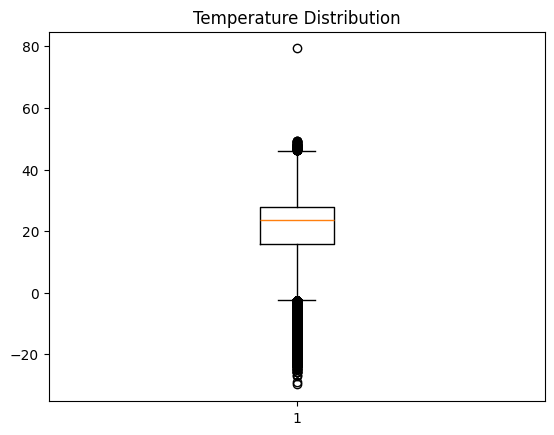

In [72]:
# temperature distribution
import matplotlib.pyplot as plt

plt.boxplot(df['temperature_celsius'])
plt.title('Temperature Distribution')
plt.show()

(array([1.000e+00, 1.000e+00, 0.000e+00, 2.000e+00, 1.000e+00, 4.000e+00,
        7.000e+00, 1.400e+01, 1.400e+01, 3.000e+00, 2.600e+01, 2.500e+01,
        3.400e+01, 2.500e+01, 1.800e+01, 4.200e+01, 5.000e+01, 4.500e+01,
        2.900e+01, 2.700e+01, 5.600e+01, 5.800e+01, 5.900e+01, 3.900e+01,
        5.200e+01, 9.400e+01, 1.130e+02, 1.210e+02, 9.600e+01, 1.080e+02,
        1.960e+02, 2.440e+02, 2.180e+02, 1.760e+02, 3.700e+02, 5.260e+02,
        6.870e+02, 6.880e+02, 5.730e+02, 9.710e+02, 1.223e+03, 1.247e+03,
        8.340e+02, 1.020e+03, 1.554e+03, 1.789e+03, 1.608e+03, 1.109e+03,
        1.377e+03, 2.187e+03, 2.393e+03, 1.876e+03, 1.613e+03, 2.184e+03,
        2.455e+03, 2.581e+03, 1.978e+03, 1.783e+03, 2.691e+03, 3.173e+03,
        3.097e+03, 2.429e+03, 2.653e+03, 4.310e+03, 4.490e+03, 4.683e+03,
        4.070e+03, 4.331e+03, 7.490e+03, 8.616e+03, 5.953e+03, 5.746e+03,
        7.209e+03, 8.105e+03, 6.508e+03, 3.514e+03, 2.793e+03, 3.149e+03,
        2.836e+03, 2.024e+03, 8.800e+0

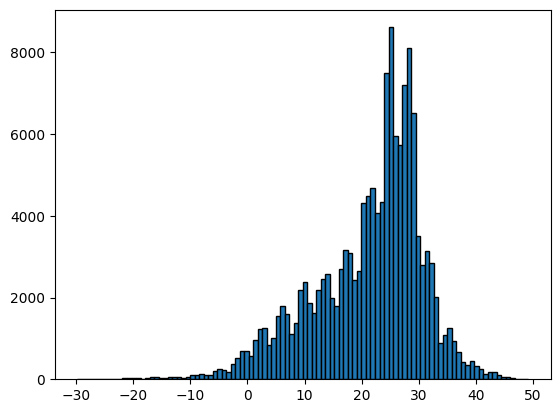

In [106]:
# temperature celsius - bell curve

plt.hist(df['temperature_celsius'], bins=100, edgecolor='black')

In [74]:
# IQR method to detect outliers in temperature_celsius

Q1 = df['temperature_celsius'].quantile(0.25)
Q3 = df['temperature_celsius'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['temperature_celsius'] < lower) |
    (df['temperature_celsius'] > upper)
]

print(outliers.shape)

(2381, 41)


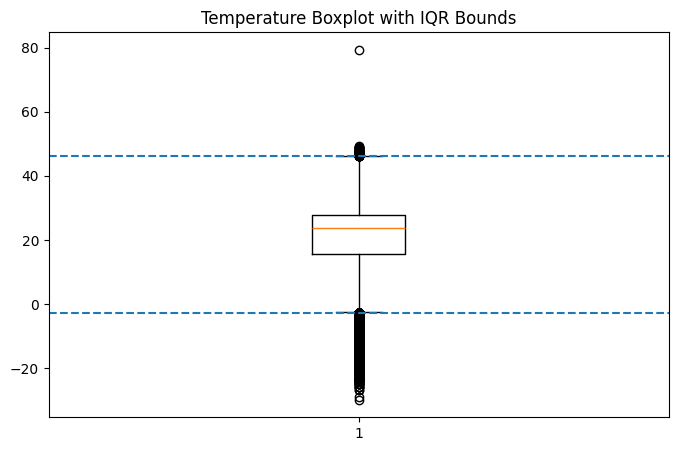

In [75]:
plt.figure(figsize=(8,5))

plt.boxplot(df['temperature_celsius'])

plt.axhline(lower, linestyle='--')
plt.axhline(upper, linestyle='--')

plt.title('Temperature Boxplot with IQR Bounds')

plt.show()

In [79]:
outliers.sort_values(
    'temperature_celsius'
).head(20)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
118990,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768719600,2026-01-18 15:00:00,-29.8,-21.6,Mist,4.0,6.5,343,NNW,1029.0,30.39,0.0,0.0,56,0,-36.7,-34.0,10.0,6.0,0.6,8.5,13.6,207.85,72.0,4.250,10.850,9.150,9.350,1,1,2026-05-27 08:35:00,2026-05-27 17:31:00,2026-05-27 08:39:00,2026-05-27 16:36:00,Waning Crescent,1
119182,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768893300,2026-01-20 15:15:00,-28.9,-20.0,Sunny,4.0,6.5,280,W,1027.0,30.33,0.0,0.0,62,0,-35.6,-32.1,8.0,4.0,1.0,4.7,7.6,1915.85,26.0,42.650,41.450,59.450,60.650,3,8,2026-05-27 08:33:00,2026-05-27 17:34:00,2026-05-27 09:33:00,2026-05-27 19:04:00,Waxing Crescent,1
121617,Belarus,Minsk,53.9000,27.5667,Europe/Minsk,1770015600,2026-02-02 10:00:00,-26.9,-16.4,Freezing fog,6.9,11.2,331,NNW,1019.0,30.09,0.0,0.0,83,0,-36.0,-32.8,10.0,6.0,0.2,14.6,23.4,237.85,47.0,7.950,3.950,10.350,14.950,1,1,2026-05-27 08:55:00,2026-05-27 17:53:00,2026-05-27 18:36:00,2026-05-27 09:24:00,Waning Gibbous,100
118606,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768547700,2026-01-16 15:15:00,-26.8,-16.2,Mist,3.8,6.1,74,ENE,1021.0,30.15,0.0,0.0,69,0,-32.9,-27.3,10.0,6.0,0.6,8.0,12.9,745.85,68.0,12.450,47.550,14.250,14.950,1,2,2026-05-27 08:36:00,2026-05-27 17:28:00,2026-05-27 07:09:00,2026-05-27 14:30:00,Waning Crescent,9
118801,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768633200,2026-01-17 15:00:00,-25.9,-14.6,Partly cloudy,4.0,6.5,341,NNW,1019.0,30.09,0.0,0.0,69,50,-32.2,-25.9,8.0,4.0,0.5,8.5,13.6,348.85,69.0,10.650,15.250,17.050,17.350,2,2,2026-05-27 08:36:00,2026-05-27 17:30:00,2026-05-27 07:59:00,2026-05-27 15:29:00,Waning Crescent,5
118507,Belarus,Minsk,53.9000,27.5667,Europe/Minsk,1768547700,2026-01-16 10:15:00,-25.8,-14.4,Freezing fog,4.3,6.8,146,SSE,1035.0,30.56,0.0,0.0,76,25,-32.3,-26.1,9.0,5.0,0.0,8.9,14.4,380.85,13.0,30.750,9.750,26.950,27.550,2,3,2026-05-27 09:19:00,2026-05-27 17:21:00,2026-05-27 08:24:00,2026-05-27 14:13:00,Waning Crescent,8
115680,Russia,Chi-Chi-Erh,51.7000,94.4500,Asia/Krasnoyarsk,1767251700,2026-01-01 14:15:00,-25.8,-14.4,Mist,2.2,3.6,235,SW,1048.0,30.95,0.0,0.0,94,78,-25.8,-14.4,2.0,1.0,0.6,2.3,3.8,161.85,73.0,6.650,3.550,12.550,14.250,1,2,2026-05-27 07:35:00,2026-05-27 17:20:00,2026-05-27 14:58:00,2026-05-27 05:27:00,Waxing Gibbous,90
118774,Kazakhstan,Astana,51.1811,71.4278,Asia/Almaty,1768633200,2026-01-17 12:00:00,-25.7,-14.3,Partly Cloudy,4.9,7.9,124,SE,1047.0,30.92,0.0,0.0,76,0,-32.9,-27.2,10.0,6.0,1.0,8.9,14.4,360.85,35.0,23.050,21.950,7.350,7.650,1,1,2026-05-27 08:10:00,2026-05-27 16:39:00,2026-05-27 07:47:00,2026-05-27 14:35:00,Waning Crescent,4
119376,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768978800,2026-01-21 15:00:00,-25.7,-14.3,Partly Cloudy,2.2,3.6,209,SSW,1023.0,30.21,0.0,0.0,57,0,-29.3,-20.8,6.0,3.0,0.8,6.7,10.8,1387.85,8.0,61.850,26.450,81.450,82.850,4,10,2026-05-27 08:32:00,2026-05-27 17:35:00,2026-05-27 09:52:00,2026-05-27 20:19:00,Waxing Crescent,3
120074,Canada,Ottawa,45.4167,-75.7000,America/Toronto,1769324400,2026-01-25 02:00:00,-25.0,-13.0,Partly cloudy,2.5,4.0,44,NE,1038.0,30.65,0.0,0.0,63,50,-28.9,-20.1,24.0,14.0,0.0,5.2,8.3,502.85,25.0,38.350,8.550,14.050,14.350,1,2,2026-05-27 07:31:00,2026-05-27 17:00:00,2026-05-27 10:22:00,NaT,First Quarter,39


In [ ]:
outliers.sort_values(
    'temperature_celsius',
    ascending=False
).head(20)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
137276,Fiji Islands,Suva,-18.1333,178.4167,Pacific/Fiji,1777012200,2026-04-24 18:30:00,79.3,174.7,Partly cloudy,10.1,16.2,121,ESE,1013.0,29.91,0.99,0.04,7,50,81.3,178.3,10.0,6.0,0.0,16.8,27.1,75.85,13.0,2.750,1.350,4.250,5.950,1,1,2026-05-27 06:18:00,2026-05-27 17:51:00,2026-05-27 12:53:00,NaT,First Quarter,43
6896,Kuwait,Kuwait City,29.3700,47.9600,Asia/Kuwait,1718804700,2024-06-19 16:45:00,49.2,120.6,Sunny,13.6,22.0,330,NNW,996.0,29.42,0.00,0.00,4,0,51.2,124.2,14.0,8.0,10.0,24.3,39.2,208.60,135.9,3.700,0.800,33.600,187.000,2,3,2026-05-27 04:49:00,2026-05-27 18:50:00,2026-05-27 16:33:00,2026-05-27 02:17:00,Waxing Gibbous,90
7460,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1719063900,2024-06-22 16:45:00,49.1,120.4,Partly cloudy,6.9,11.2,200,SSW,994.0,29.36,0.00,0.00,8,25,51.1,124.0,10.0,6.0,11.0,11.1,17.8,208.60,148.8,3.800,2.300,16.100,47.900,2,2,2026-05-27 04:54:00,2026-05-27 19:16:00,2026-05-27 20:06:00,2026-05-27 04:42:00,Full Moon,100
11145,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1720701900,2024-07-11 15:45:00,49.1,120.3,Sunny,12.8,20.5,307,NW,999.0,29.50,0.00,0.00,6,0,51.1,123.9,10.0,6.0,11.0,14.7,23.6,210.30,157.4,4.200,3.600,12.300,39.500,1,2,2026-05-27 05:02:00,2026-05-27 19:14:00,2026-05-27 09:58:00,2026-05-27 22:37:00,Waxing Crescent,23
8425,Kuwait,Kuwait City,29.3700,47.9600,Asia/Kuwait,1719494100,2024-06-27 16:15:00,48.9,120.0,Sunny,13.6,22.0,310,NW,993.0,29.33,0.00,0.00,4,0,50.9,123.6,9.7,6.0,10.0,29.6,47.6,198.60,140.2,5.800,3.000,29.000,133.500,2,3,2026-05-27 04:51:00,2026-05-27 18:52:00,2026-05-27 23:08:00,2026-05-27 10:13:00,Waning Gibbous,71
85049,Kuwait,Kuwait City,29.3667,47.9600,Asia/Kuwait,1753691400,2025-07-28 11:30:00,48.8,119.8,Sunny,2.2,3.6,225,SW,995.0,29.38,0.00,0.00,5,0,50.8,123.4,10.0,6.0,10.5,3.6,5.7,530.95,66.0,37.555,15.725,100.640,503.015,4,10,2026-05-27 05:06:00,2026-05-27 18:43:00,2026-05-27 08:26:00,2026-05-27 21:03:00,Waxing Crescent,11
11338,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1720788300,2024-07-12 15:45:00,48.8,119.8,Sunny,22.4,36.0,317,NW,995.0,29.39,0.00,0.00,6,0,50.8,123.4,10.0,6.0,11.0,25.7,41.4,196.90,183.1,2.800,11.200,18.400,50.600,2,2,2026-05-27 05:02:00,2026-05-27 19:14:00,2026-05-27 10:53:00,2026-05-27 23:01:00,Waxing Crescent,32
76862,Kuwait,Kuwait City,29.3667,47.9600,Asia/Kuwait,1750064400,2025-06-16 12:00:00,48.6,119.5,Sunny,8.1,13.0,305,NW,996.0,29.42,0.00,0.00,4,0,50.6,123.1,10.0,6.0,11.3,16.9,27.2,392.20,61.0,99.715,36.075,80.475,228.290,4,10,2026-05-27 04:48:00,2026-05-27 18:50:00,2026-05-27 22:51:00,2026-05-27 09:18:00,Waning Gibbous,80
7270,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1718976600,2024-06-21 16:30:00,48.4,119.1,Sunny,10.5,16.9,270,W,998.0,29.46,0.00,0.00,8,0,50.4,122.7,10.0,6.0,11.0,22.4,36.0,205.30,137.3,2.700,2.100,16.400,51.100,2,2,2026-05-27 04:53:00,2026-05-27 19:15:00,2026-05-27 19:06:00,2026-05-27 03:47:00,Full Moon,99
9975,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1720183500,2024-07-05 15:45:00,48.3,118.9,Sunny,21.7,34.9,330,NNW,995.0,29.38,0.00,0.00,6,0,50.3,122.5,10.0,6.0,11.0,23.2,37.3,212.00,186.0,3.000,8.100,23.200,97.300,2,2,2026-05-27 04:59:00,2026-05-27 19:16:00,2026-05-27 03:56:00,2026-05-27 19:16:00,New Moon,1


In [ ]:
# All temperature outliers are plausible except Fiji
# Checking other records from Fiji

df_temp = df[df['location_name'] == 'Suva']
df_temp['temperature_celsius'].where(df_temp['temperature_celsius'] < 79).describe()

count    739.000000
mean      24.811231
std        2.208599
min       17.300000
25%       23.300000
50%       25.000000
75%       26.200000
max       30.400000
Name: temperature_celsius, dtype: float64

In [88]:
df[df['temperature_celsius'] > 79][
    [
        'country',
        'location_name',
        'temperature_celsius',
        'temperature_fahrenheit',
        'feels_like_celsius',
        'feels_like_fahrenheit'
    ]
]

,country,location_name,temperature_celsius,temperature_fahrenheit,feels_like_celsius,feels_like_fahrenheit
137276,Fiji Islands,Suva,79.3,174.7,81.3,178.3


In [89]:
# This record from Fiji with temperature > 79C has all other values regarding temperature similar to the outlier.
# Removing this record from the dataset

df = df[df['temperature_celsius'] <= 79]

In [90]:
df.shape

(143846, 41)

#### Checking for outliers/consistency issues in other features

##### Location related features

In [101]:
countries = sorted(df['country'].unique())
display(countries)

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Bélgica',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Estonie',
 'Ethiopia',
 'Fiji Islands',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guatemala',
 'Guinea',
 'Guinea-Bissau',
 'Guya

In [102]:
cities = sorted(df['location_name'].unique())
display(cities) 

["'S Gravenjansdijk",
 "'S Gravenjansdyk",
 "'S Gravenstaffel",
 "'S-Gravenbrakel",
 '-Kingdom',
 'Abu Dhabi',
 'Abuja',
 'Accra',
 'Addis Ababa',
 'Addis Abeba',
 'Adkip',
 'Aguaray',
 'Airai',
 'Algiers',
 'Amman',
 'Amsterdam',
 'Andorra La Vella',
 'Ankara',
 'Antananarivo',
 'Apia',
 'Ar Riyadh',
 'Ashgabat',
 'Asmara',
 'Astana',
 'Asuncion',
 'Athens',
 'Aurora',
 'Bafoussam',
 'Baghdad',
 'Baku',
 'Bali',
 'Bamako',
 'Ban Lom',
 'Bandar Seri Begawan',
 'Bangkok',
 'Bangui',
 'Banjul',
 'Basseterre',
 'Beijing',
 'Beijing Shi',
 'Beirut',
 'Belgrade',
 'Belmopan',
 'Berlin',
 'Bern',
 'Bishkek',
 'Bissau',
 'Bogot',
 'Bogota',
 'Bras',
 'Bratislava',
 'Brazzaville',
 'Bridgetown',
 'Brussels',
 'Bucharest',
 'Budapest',
 'Buenos Aires',
 'Bujumbura',
 'Cairo',
 'Canberra',
 'Caracas',
 'Carreria',
 'Castries',
 'Chi Chi Khvar',
 'Chi-Chi-Erh',
 'City Of San Marino',
 'Colombo',
 'Conakry',
 'Copenhagen',
 'Costa Rica',
 'Dakar',
 'Damascus',
 'Dhaka',
 'Dhidhdhoo',
 'Dili',
 'Dj

In [105]:
print(len(countries), len(cities))

211 257


(array([7.380e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.476e+03, 7.370e+02,
        0.000e+00, 7.360e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 7.370e+02, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 7.370e+02, 1.478e+03, 1.000e+00, 1.197e+03, 0.000e+00,
        4.240e+02, 7.390e+02, 1.000e+01, 2.500e+01, 7.370e+02, 0.000e+00,
        9.920e+02, 7.580e+02, 7.390e+02, 7.390e+02, 1.476e+03, 0.000e+00,
        0.000e+00, 0.000e+00, 7.390e+02, 0.000e+00, 1.472e+03, 0.000e+00,
        0.000e+00, 7.350e+02, 7.370e+02, 7.340e+02, 0.000e+00, 0.000e+00,
        1.478e+03, 2.214e+03, 7.380e+02, 0.000e+00, 1.000e+00, 1.477e+03,
        0.000e+00, 0.000e+00, 7.370e+02, 1.475e+03, 7.400e+02, 0.000e+00,
        7.340e+02, 7.390e+02, 1.477e+03, 0.000e+00, 7.350e+02, 1.477e+03,
        7.390e+02, 0.000e+00, 7.370e+02, 7.380e+02, 7.740e+02, 1.035e+03,
        7.390e+02, 7.580e+02, 7.370e+0

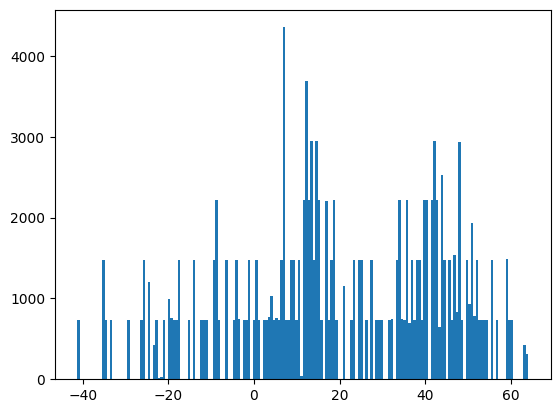

In [123]:
# check normal distribution for latitude

plt.hist(df['latitude'], bins=180)

In [116]:
df[(df['latitude'] > 60) | (df['latitude'] < -40)][
    ['country', 'location_name', 'latitude']
].drop_duplicates()

,country,location_name,latitude
59,Finland,Helsinki,60.1800
76,Iceland,Grindavik,63.8300
123,New Zealand,Wellington,-41.3000
7074,Iceland,Vestmannaeyjar,63.3700
8032,Iceland,Reykjavik,64.1500
27036,Finland,Helsinki,60.1756
27053,Iceland,Vestmannaeyjar,63.3650


(array([7.370e+02, 0.000e+00, 0.000e+00, 7.330e+02, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 7.140e+02, 0.000e+00,
        0.000e+00, 1.600e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 7.340e+02,
        0.000e+00, 0.000e+00, 0.000e+0

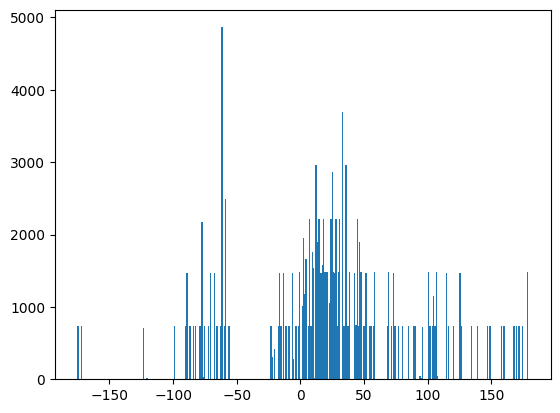

In [124]:
# check normal distribution for longitude

plt.hist(df['longitude'], bins=360)

Longitude distributions showed higher observation density around major populated continental regions, while sparse regions likely corresponded to oceanic areas with lower weather station or city representation.

In [ ]:
df[(df['longitude'] > 150) | (df['longitude'] < -150)][
    ['country', 'location_name', 'longitude']
].drop_duplicates()

,country,location_name,longitude
58,Fiji Islands,Suva,178.4200
89,Kiribati,Tarawa,169.5300
107,Marshall Islands,Majuro,171.3800
111,Micronesia,Palikir,158.1500
123,New Zealand,Wellington,174.7800
148,Samoa,Apia,-171.7300
159,Solomon Islands,Honiara,159.9500
176,Tonga,Nuku`Aloia,-175.2000
181,Tuvalu,Funafuti,179.2200
189,Vanuatu,Port Vila,168.3200


In [126]:
display(df['timezone'].unique())

<StringArray>
[                    'Asia/Kabul',                  'Europe/Tirane',
                 'Africa/Algiers',                 'Europe/Andorra',
                  'Africa/Luanda',                'America/Antigua',
 'America/Argentina/Buenos_Aires',                   'Asia/Yerevan',
               'Australia/Sydney',                  'Europe/Vienna',
 ...
             'America/Hermosillo',                'Africa/Kinshasa',
                'Africa/Ndjamena',                   'Asia/Nicosia',
                 'Europe/Vatican',                  'Africa/Maseru',
              'Europe/San_Marino',                 'Africa/Abidjan',
               'Asia/Krasnoyarsk',                    'Europe/Kyiv']
Length: 199, dtype: str

In [135]:
df.isna().sum()

country                            0
location_name                      0
latitude                           0
longitude                          0
timezone                           0
last_updated_epoch                 0
last_updated                       0
temperature_celsius                0
temperature_fahrenheit             0
condition_text                     0
wind_mph                           0
wind_kph                           0
wind_degree                        0
wind_direction                     0
pressure_mb                        0
pressure_in                        0
precip_mm                          0
precip_in                          0
humidity                           0
cloud                              0
feels_like_celsius                 0
feels_like_fahrenheit              0
visibility_km                      0
visibility_miles                   0
uv_index                           0
gust_mph                           0
gust_kph                           0
a

In [136]:
df['condition_text'].unique()

<StringArray>
[                              'Partly Cloudy',
                               'Partly cloudy',
                                       'Sunny',
                               'Light drizzle',
                                       'Clear',
                                    'Overcast',
         'Moderate or heavy rain with thunder',
      'Patchy light rain in area with thunder',
                                         'Fog',
              'Patchy light rain with thunder',
                          'Patchy rain nearby',
                                  'Light rain',
                                        'Mist',
                                      'Cloudy',
                'Thundery outbreaks in nearby',
                               'Moderate rain',
                           'Light rain shower',
                      'Moderate rain at times',
               'Moderate or heavy rain shower',
                         'Heavy rain at times',
                          

##### Wind related features

(2252, 41)


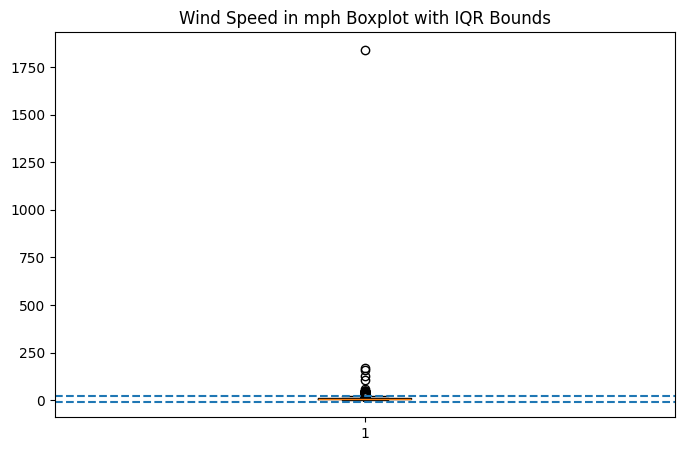

In [141]:
# boxplots for wind_mph and wind_kph

# IQR method to detect outliers in wind_mph

Q1 = df['wind_mph'].quantile(0.25)
Q3 = df['wind_mph'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['wind_mph'] < lower) |
    (df['wind_mph'] > upper)
]

print(outliers.shape)

plt.figure(figsize=(8,5))

plt.boxplot(df['wind_mph'])

plt.axhline(lower, linestyle='--')
plt.axhline(upper, linestyle='--')

plt.title('Wind Speed in mph Boxplot with IQR Bounds')

plt.show()

In [138]:
df['wind_mph'].where(df['wind_mph'] < 1750).describe()

count    143845.000000
mean          7.966035
std           5.208664
min           2.200000
25%           3.800000
50%           6.700000
75%          11.000000
max         169.100000
Name: wind_mph, dtype: float64

In [140]:
df[df['wind_mph'] > 1750]

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
7601,Burundi,Bujumbura,-3.38,29.36,Africa/Bujumbura,1719150300,2024-06-23 15:45:00,22.5,72.6,Partly cloudy,1841.2,2963.2,180,S,1014.0,29.94,0.0,0.0,52,25,24.6,76.3,10.0,6.0,7.0,1845.7,2970.4,277.0,52.2,0.6,0.2,5.3,7.2,1,1,2026-05-27 06:07:00,2026-05-27 18:03:00,2026-05-27 19:36:00,2026-05-27 07:19:00,Waning Gibbous,99


Historical maximum wind speed ever observed was recorded during Oklahoma Tornado on May 3, 1999 to be 321 mph (517 kph). Deleting this record as wind_mph, wind_kph, gust_mph and gust_kph all show implausible values.

In [142]:
df.shape

(143846, 41)

In [146]:
df = df[df['wind_mph'] < 400]

In [147]:
df.shape

(143845, 41)

Outliers in wind_mph: 2251


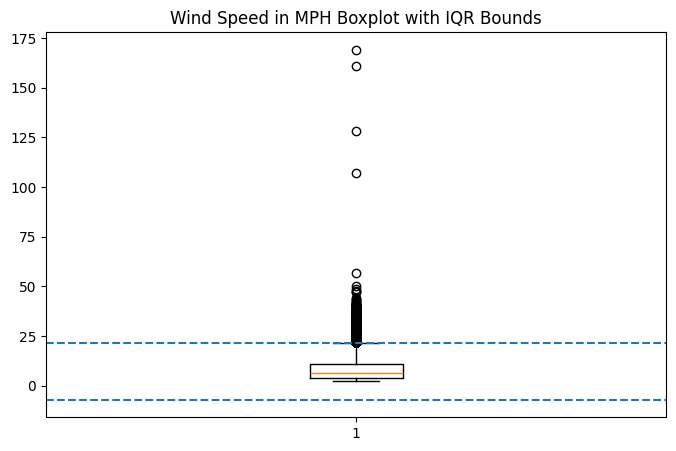

Outliers in wind_kph: 2439


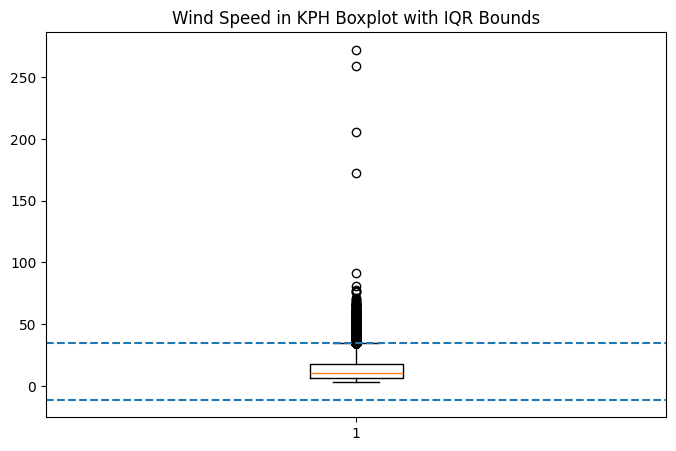

Outliers in gust_mph: 3813


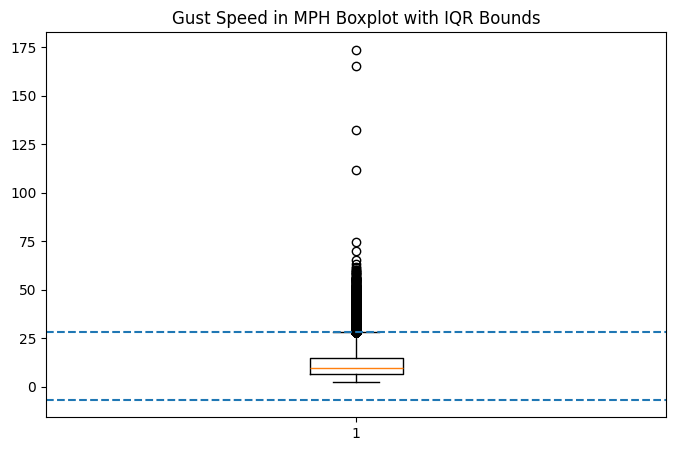

Outliers in gust_kph: 3900


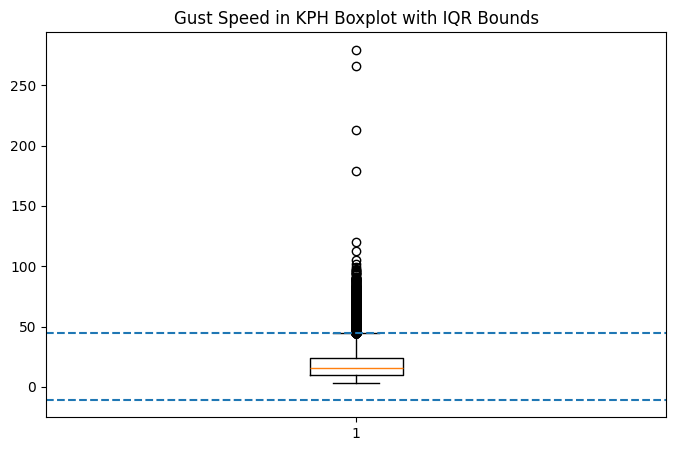

In [151]:
# boxplots for wind and gust speeds
# IQR method to detect outliers

wind_columns = ['wind_mph', 'wind_kph', 'gust_mph', 'gust_kph']

for col in wind_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Outliers in {col}: {outliers.shape[0]}")

    plt.figure(figsize=(8,5))

    plt.boxplot(df[col])

    plt.axhline(lower, linestyle='--')
    plt.axhline(upper, linestyle='--')

    plt.title(f'{col.split("_")[0].title()} Speed in {col.split("_")[1].upper()} Boxplot with IQR Bounds')

    plt.show()

In [155]:
# Wind direction is circular data - 1 to 360

df['wind_degree'].min(), df['wind_degree'].max()

(np.int64(1), np.int64(360))

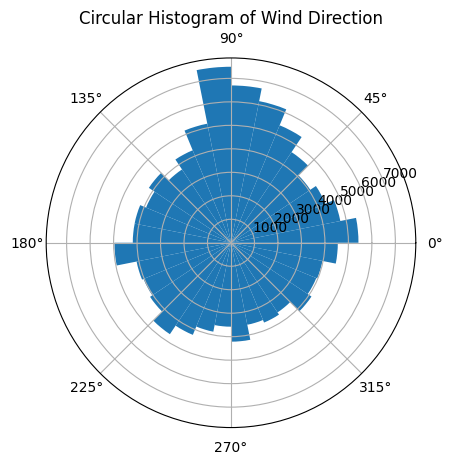

In [ ]:
# Needs circular plots and directional statistics (not linear)

# Convert degrees to radians
angles = np.deg2rad(df['wind_degree'])

# Create bins
num_bins = 32
bins = np.linspace(0, 2 * np.pi, num_bins + 1)

# Count frequencies
counts, _ = np.histogram(angles, bins=bins)

# Plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

ax.bar(
    bins[:-1],
    counts,
    width=(2 * np.pi / num_bins),
    align='edge'
)

ax.set_title('Circular Histogram of Wind Direction')

plt.show()

In [160]:
# Check if the above plot is consistent with 16 point wind_direction

df['wind_direction'].unique()

<StringArray>
['NNW',  'NW',   'W',  'SW', 'SSE',   'E',   'N',  'SE', 'ESE', 'NNE',   'S',
 'WSW', 'SSW', 'ENE',  'NE', 'WNW']
Length: 16, dtype: str

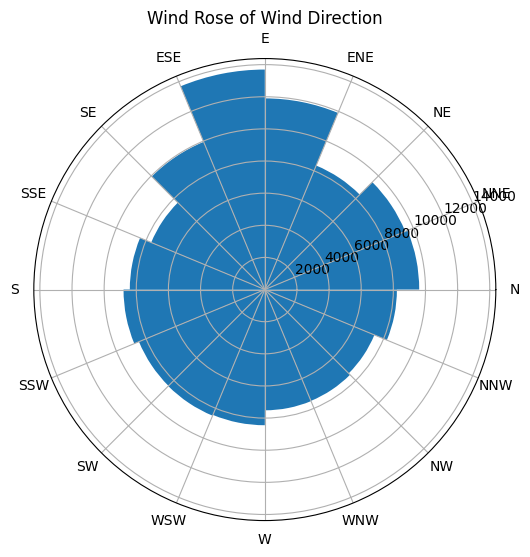

In [162]:
# Order compass directions properly
directions = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

# Count frequencies
counts = df['wind_direction'].value_counts()

# Ensure consistent order
counts = [counts.get(d, 0) for d in directions]

# Angles
angles = np.linspace(0, 2 * np.pi, len(directions), endpoint=False)

# Plot
fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': 'polar'})

ax.bar(
    angles,
    counts,
    width=2*np.pi/len(directions),
    align='edge'
)

# Labels
ax.set_xticks(angles)
ax.set_xticklabels(directions)

ax.set_title('Wind Rose of Wind Direction')

plt.show()

Both the continuous circular histogram (`wind_degree`) and the categorical wind rose (`wind_direction`) showed similar directional distributions, indicating internal consistency between the two representations. No obvious anomalous or invalid directional values were observed.